In [1]:
import sys
sys.path.insert(0, "..")

In [2]:
import os
import torch
import wandb
import shutil
import numpy as np
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import torchvision.utils as vutils

from matplotlib.gridspec import GridSpec
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from cleanfid import fid

from mean_flow.models import UNet

In [3]:
ENTITY = "zhangk15"        
PROJECT = "mean-flow"       
RUN_ID = "k387c0gu"     

In [4]:
run = wandb.init()
artifact = run.use_artifact(f'{ENTITY}/{PROJECT}/model-{RUN_ID}:best_k', type='model')
artifact_dir = artifact.download()

wandb: Currently logged in as: zhangk15 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb:   1 of 1 files downloaded.  


In [5]:
model_file_path = f"{artifact_dir}/model.ckpt"

In [6]:
ckpt = torch.load(model_file_path, map_location="cpu", weights_only=False)

In [7]:
net_state_dict = {k.replace("net.", ""): v for k, v in ckpt["state_dict"].items()}

In [8]:
net_state_dict = {}
for k, v in ckpt["state_dict"].items():
    if k[:4] == "net.":
        net_state_dict[k.replace("net.", "")] = v

In [9]:
model = UNet(image_size=32,
             in_channels=1,
             model_channels=32,
             out_channels=1,
             num_res_blocks=1,
             attention_resolutions=[],
             channel_mult=(1, 2, 4))   

model.load_state_dict(net_state_dict)
model.eval();

In [10]:
device = next(model.parameters()).device

In [11]:
def sample(model, device, e, step=1):
    if step == 1:
        r = torch.zeros(e.shape[0], device=device)
        t = torch.ones(e.shape[0], device=device)
        return e - model(e, r, t)
    
    ts = torch.linspace(1, 0, step + 1, device=device)
    x = e.clone()
    
    for i in range(step):
        t = ts[i].expand(x.shape[0])
        r = ts[i + 1].expand(x.shape[0])
        u = model(x, r, t)
        dt = ts[i] - ts[i + 1]
        x = x - dt * u
    return x

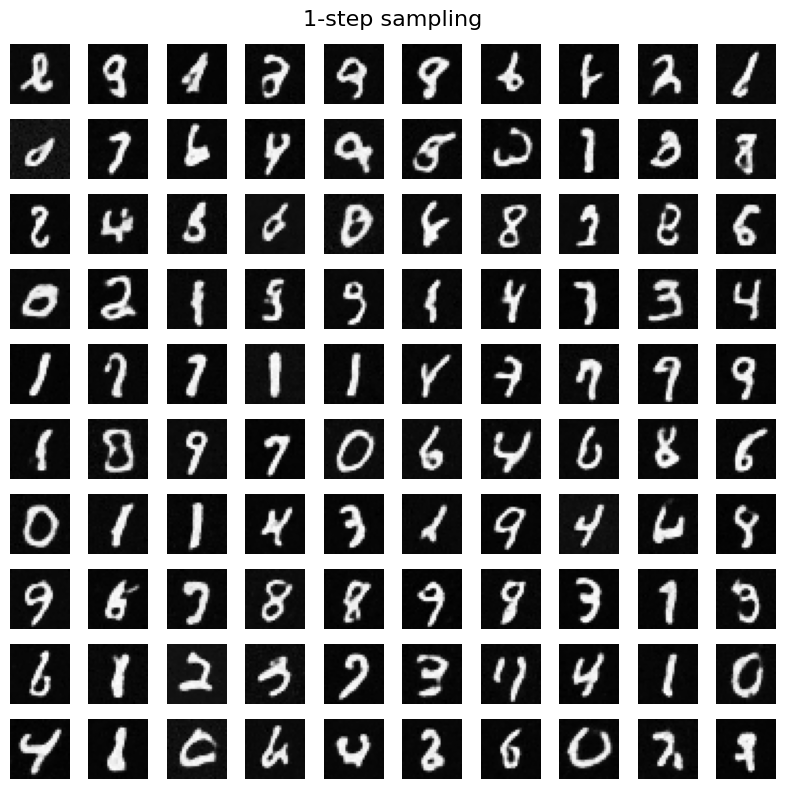

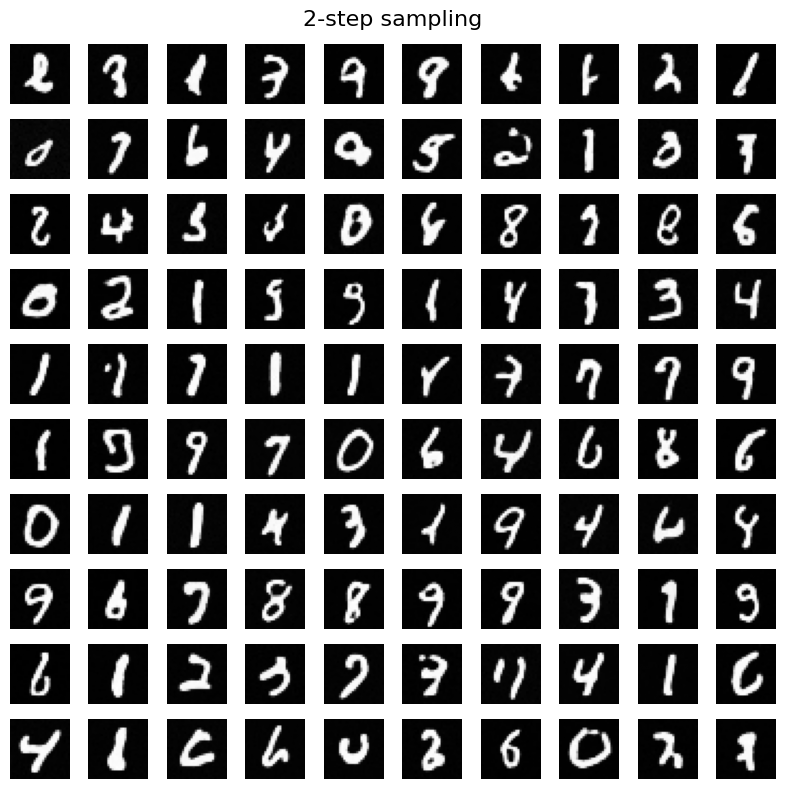

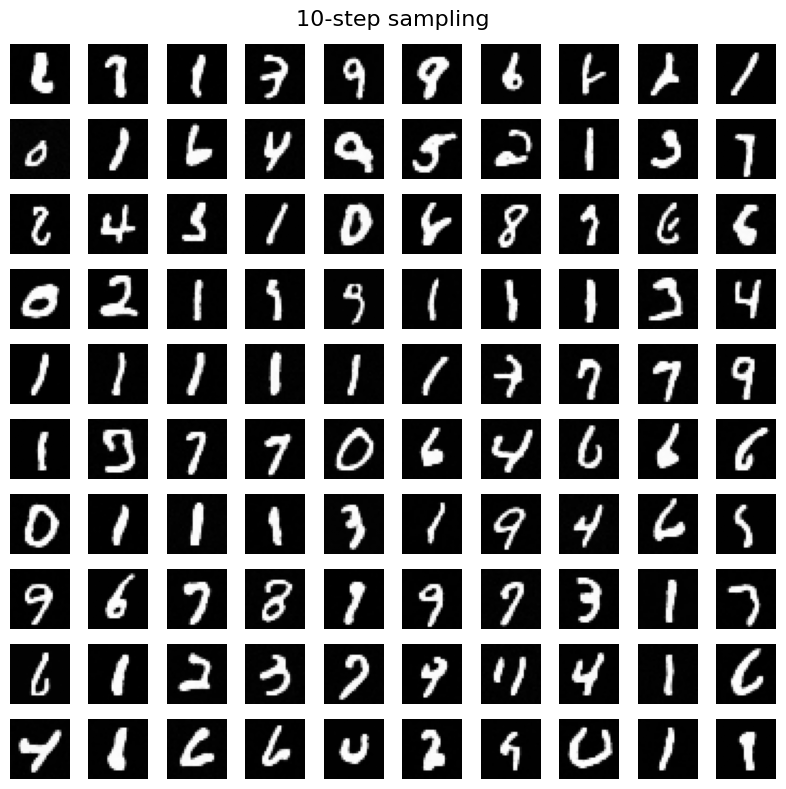

In [12]:
steps = [1, 2, 10]

noises = torch.randn(100, 1, 32, 32).to(device)  
reverse_transform = transforms.CenterCrop(28)

for step in steps:
    samples = reverse_transform(sample(model=model, device=device, e=noises, step=step))
    images = samples.cpu().detach().numpy()

    fig, axes = plt.subplots(10, 10, figsize=(8, 8))
    fig.suptitle(f"{step}-step sampling", fontsize=16)
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i, 0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [13]:
test_dataset = datasets.MNIST(root="./data", train=False, download=True,
                               transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

folder = "real"
shutil.rmtree(folder, ignore_errors=True)

os.makedirs(folder)
count = 0
for batch in test_loader:
    images, _ = batch
    for img in images:
        if count >= 1000:  # or 10000 for full test set
            break
        vutils.save_image(img, f"real/real_{count:04d}.png")
        count += 1

In [14]:
with torch.no_grad():
    for step in steps:
        z = torch.randn(1000, 1, 32, 32).to(device)
        
        fake = sample(model=model, device=device, e=z, step=step)
        images = reverse_transform(fake)

        folder = f"fake_{step}_step"
        shutil.rmtree(folder, ignore_errors=True)
        
        os.makedirs(folder, exist_ok=True)
        for i, img in enumerate(images):
            vutils.save_image(img.cpu(), os.path.join(folder, f"{folder}_{i:04d}.png"))

In [15]:
fid_scores = {step:fid.compute_fid(f"fake_{step}_step","real") for step in steps}

compute FID between two folders
Found 1000 images in the folder fake_1_step


FID fake_1_step : 100%|█████████████████████████████████████████████████████████████████| 32/32 [00:04<00:00,  6.79it/s]


Found 1000 images in the folder real


FID real : 100%|████████████████████████████████████████████████████████████████████████| 32/32 [00:04<00:00,  7.50it/s]


compute FID between two folders
Found 1000 images in the folder fake_2_step


...

FID real : 100%|████████████████████████████████████████████████████████████████████████| 32/32 [00:04<00:00,  7.61it/s]


compute FID between two folders
Found 1000 images in the folder fake_10_step


FID fake_10_step : 100%|████████████████████████████████████████████████████████████████| 32/32 [00:04<00:00,  7.35it/s]


Found 1000 images in the folder real


FID real : 100%|████████████████████████████████████████████████████████████████████████| 32/32 [00:04<00:00,  7.67it/s]


In [16]:
print("Clean-FID score:")

for step in steps:
    print(f"{step}-step samples:", fid_scores[step])

Clean-FID score:
1-step samples: 48.92018386906142
2-step samples: 56.76102028915457
10-step samples: 61.001101621192106


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import os

# ===== 1. Classifier definition =====
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(5 * 5 * 64, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

# ===== 2. Train classifier if not exist =====
def train_classifier(device="cuda"):
    model = MNISTClassifier().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    transform = transforms.ToTensor()
    train_set = datasets.MNIST("./data", train=True, download=True, transform=transform)
    test_set  = datasets.MNIST("./data", train=False, transform=transform)
    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
    test_loader  = DataLoader(test_set, batch_size=1000)

    for epoch in range(1, 6):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x).argmax(dim=1)
                correct += (pred == y).sum().item()
        acc = correct / len(test_set)
        print(f"Epoch {epoch}: Accuracy = {acc:.4f}")

    torch.save(model.state_dict(), "mnist_classifier.pt")
    return model

# ===== 3. Load or train classifier =====
def get_or_train_classifier(device="cuda"):
    clf = MNISTClassifier().to(device)
    if os.path.exists("mnist_classifier.pt"):
        clf.load_state_dict(torch.load("mnist_classifier.pt", map_location=device))
        print("Loaded pretrained classifier.")
    else:
        print("Training classifier...")
        clf = train_classifier(device)
    clf.eval()
    return clf

# ===== 4. Evaluation function =====
def evaluate_generated_images(model, clf, reverse_transform, steps=[1, 2, 10], device="cuda"):
    clf.eval()
    z = torch.randn(1000, 1, 32, 32).to(device)

    for step in steps:
        with torch.no_grad():
            fake = sample(model=model, device=device, e=z.clone(), step=step)
            fake = reverse_transform(fake).to(device)

            # Classifier output
            logits = clf(fake)
            probs = F.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            entropy = (-probs * probs.log()).sum(dim=1)
            entropy_mean = entropy.mean().item()
            pred_count = Counter(preds.cpu().numpy())

            print(f"\n🌀 {step}-Step")
            print(f"Entropy (mean): {entropy_mean:.4f}")
            
            # 可视化柱状图
            labels = list(range(10))
            counts = [pred_count.get(i, 0) for i in labels]
            
            plt.figure(figsize=(6, 3))
            plt.bar(labels, counts, color="skyblue")
            plt.xticks(labels)
            plt.xlabel("Predicted Digit")
            plt.ylabel("Count")
            plt.title(f"Step {step} Prediction Distribution")
            plt.tight_layout()
            plt.show()

In [18]:
classifier = get_or_train_classifier(device=device)

Loaded pretrained classifier.



🌀 1-Step
Entropy (mean): 0.1349


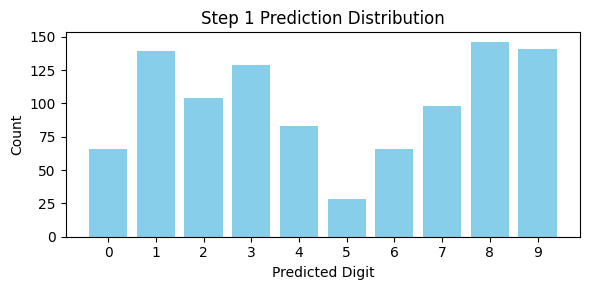


🌀 2-Step
Entropy (mean): 0.1227


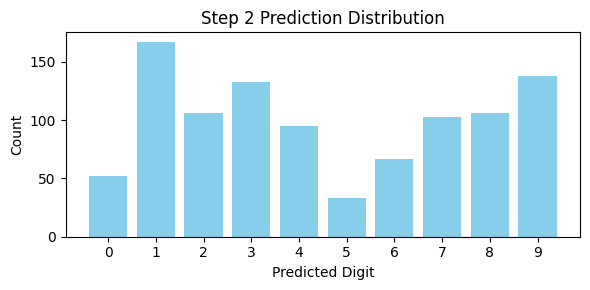


🌀 10-Step
Entropy (mean): 0.0536


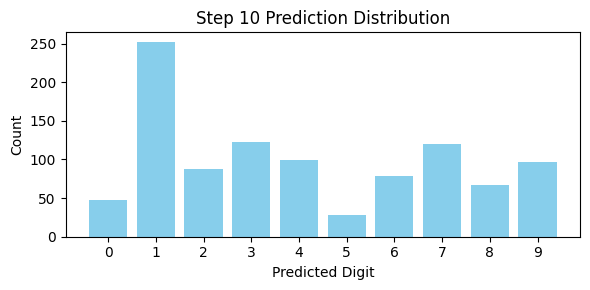

In [19]:
evaluate_generated_images(model=model, clf=classifier, reverse_transform=reverse_transform, steps=[1, 2, 10], device=device)

## 🧪 MNIST Generation: Step-wise Evaluation Summary

### 🔢 Step-wise Entropy (Classifier Uncertainty)

| Sampling Step | Mean Entropy ↓ | Interpretation                                   |
|---------------|----------------|--------------------------------------------------|
| 1-Step        | 0.1349         | Fairly confident predictions                     |
| 2-Step        | 0.1227         | Slightly more confident                         |
| 10-Step       | 0.0536         | Very confident (but potentially mode collapse)   |

> 📉 Lower entropy means the classifier is more confident, indicating sharper and more classifiable images.

---

### 📊 Prediction Distribution by Step (Histogram)

- For each step, predicted digit distributions are plotted.
- 1-step and 2-step samples show relatively balanced class coverage.
- 10-step samples show **severe mode collapse**, with digit "1" dominating.

---

### 🎯 Clean-FID Scores (Image Quality & Diversity)

| Sampling Step | Clean-FID ↓     | Interpretation                         |
|---------------|------------------|----------------------------------------|
| 1-Step        | **48.92**        | Best match to real MNIST distribution  |
| 2-Step        | 56.76            | Slightly worse                         |
| 10-Step       | **61.00**        | Worst FID, likely due to mode collapse |

> 🧠 Lower Clean-FID indicates higher image quality and better distribution alignment with real data.

---

### ✅ Summary & Insights

- **On MNIST**, fewer steps (e.g., 1-step) may yield better results:
  - Lower FID
  - Balanced class distribution
  - Sufficient classification confidence
- **10-step sampling** yields lower entropy (more confidence), but at the cost of diversity—suggesting **mode collapse**.

> 🔍 Takeaway: Simpler datasets like MNIST often benefit from fewer sampling steps. Higher step counts may help in more complex datasets (e.g., CIFAR-10, CelebA) but can harm diversity on MNIST.
